# Historical Revenue Forecasting

## Objective

Develop and evaluate a historical monthly revenue-forecasting workflow using delivered-order payment values. The analysis compares simple forecasting baselines with statistical models through time-based validation.

Revenue refers to recorded payment value associated with delivered orders in the Olist dataset. Because the data covers a limited historical period and does not represent current Olist activity, the results are presented as an offline modeling exercise rather than a business or future-revenue forecast.

## 1. Data Loading

Load the cleaned order-item, product, and category-translation tables required to construct category-level customer baskets.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images/notebook_outputs")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "primary": "#173F5F",
    "secondary": "#20639B",
    "accent": "#F6C85F",
    "positive": "#3CAEA3",
    "negative": "#ED553B",
    "neutral": "#8A8A8A"
}

order_analytics = pd.read_csv(
    DATA_DIR / "order_analytics.csv",
    parse_dates=["order_purchase_timestamp"]
)

print(
    "Order records loaded:",
    f"{len(order_analytics):,}"
)

print(
    "Purchase period:",
    order_analytics["order_purchase_timestamp"]
    .min()
    .date(),
    "to",
    order_analytics["order_purchase_timestamp"]
    .max()
    .date()
)

print(
    "Delivered orders:",
    f"{order_analytics['order_status'].eq('delivered').sum():,}"
)

Order records loaded: 99,441
Purchase period: 2016-09-04 to 2018-10-17
Delivered orders: 96,478


## 2. Construct the Monthly Revenue Series

Aggregate delivered-order payment values by purchase month and retain January 2017 through August 2018 as the comparable modeling period, excluding the sparse and incomplete boundary months.

In [3]:
delivered_orders = order_analytics.loc[
    order_analytics["order_status"].eq("delivered")
].copy()

delivered_orders["purchase_month_start"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_revenue_all = (
    delivered_orders
    .groupby(
        "purchase_month_start",
        as_index=False
    )
    .agg(
        delivered_orders=("order_id", "nunique"),
        delivered_payment_value=(
            "total_payment_value",
            "sum"
        )
    )
    .sort_values("purchase_month_start")
    .reset_index(drop=True)
)

modeling_start = pd.Timestamp("2017-01-01")
modeling_end = pd.Timestamp("2018-08-01")

monthly_revenue = (
    monthly_revenue_all.loc[
        monthly_revenue_all[
            "purchase_month_start"
        ].between(
            modeling_start,
            modeling_end
        )
    ]
    .copy()
    .reset_index(drop=True)
)

expected_months = pd.date_range(
    modeling_start,
    modeling_end,
    freq="MS"
)

missing_months = expected_months.difference(
    monthly_revenue["purchase_month_start"]
)

duplicate_months = monthly_revenue[
    "purchase_month_start"
].duplicated().sum()

print(
    "Modeling period:",
    monthly_revenue["purchase_month_start"]
    .min()
    .strftime("%Y-%m"),
    "to",
    monthly_revenue["purchase_month_start"]
    .max()
    .strftime("%Y-%m")
)

print(
    "Monthly observations:",
    f"{len(monthly_revenue):,}"
)

print(
    "Missing modeling months:",
    len(missing_months)
)

print(
    "Duplicate monthly records:",
    duplicate_months
)

display(
    monthly_revenue.style.format({
        "purchase_month_start": lambda value: (
            value.strftime("%Y-%m")
        ),
        "delivered_orders": "{:,.0f}",
        "delivered_payment_value": "R$ {:,.2f}"
    })
)

Modeling period: 2017-01 to 2018-08
Monthly observations: 20
Missing modeling months: 0
Duplicate monthly records: 0


,purchase_month_start,delivered_orders,delivered_payment_value
0,2017-01,750,"R$ 127,545.67"
1,2017-02,"1,653","R$ 271,298.65"
2,2017-03,"2,546","R$ 414,369.39"
3,2017-04,"2,303","R$ 390,952.18"
4,2017-05,"3,546","R$ 567,066.73"
5,2017-06,"3,135","R$ 490,225.60"
6,2017-07,"3,872","R$ 566,403.93"
7,2017-08,"4,193","R$ 646,000.61"
8,2017-09,"4,150","R$ 701,169.99"
9,2017-10,"4,478","R$ 751,140.27"


***Observation:*** The modeling series contains 20 complete and consecutive monthly observations with no missing or duplicate months. Delivered payment value generally increased over the period, but noticeable fluctuations—particularly the November 2017 peak—indicate that a trend alone may not explain every monthly change.

## 3. Visualize the Historical Revenue Pattern

Plot monthly delivered payment value with a three-month rolling average to examine the overall direction and short-term fluctuations before selecting forecasting methods.

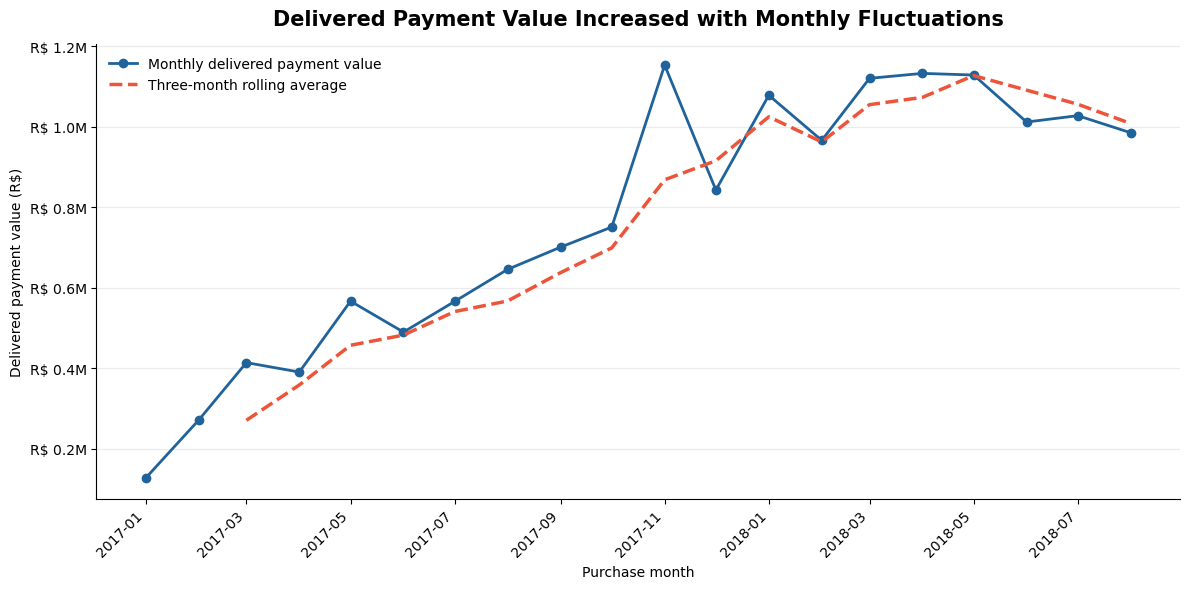

In [4]:
monthly_revenue["rolling_3_month_revenue"] = (
    monthly_revenue["delivered_payment_value"]
    .rolling(window=3)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_revenue["purchase_month_start"],
    monthly_revenue["delivered_payment_value"],
    marker="o",
    linewidth=2,
    color=COLORS["secondary"],
    label="Monthly delivered payment value"
)

ax.plot(
    monthly_revenue["purchase_month_start"],
    monthly_revenue["rolling_3_month_revenue"],
    linewidth=2.5,
    linestyle="--",
    color=COLORS["negative"],
    label="Three-month rolling average"
)

ax.set_title(
    "Delivered Payment Value Increased with Monthly Fluctuations",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Purchase month")
ax.set_ylabel("Delivered payment value (R$)")

ax.yaxis.set_major_formatter(
    lambda value, position: f"R$ {value / 1_000_000:.1f}M"
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left"
)

fig.autofmt_xdate(
    rotation=45,
    ha="right"
)

plt.tight_layout()

output_path = (
    IMAGES_DIR
    / "historical_monthly_delivered_payment_value.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Delivered payment value shows a strong upward movement through 2017, followed by stabilization near R$1.0–R$1.1 million during 2018. The series also contains substantial short-term variation, so forecasting performance must be assessed against simple baselines using unseen months.

## 4. Create a Time-Based Train-Test Split

Reserve the final four months for evaluation so that every forecasting method is trained only on information available before the test period.

In [5]:
test_months = 4

train_revenue = monthly_revenue.iloc[
    :-test_months
].copy()

test_revenue = monthly_revenue.iloc[
    -test_months:
].copy()

train_end = train_revenue[
    "purchase_month_start"
].max()

test_start = test_revenue[
    "purchase_month_start"
].min()

test_end = test_revenue[
    "purchase_month_start"
].max()

print(
    "Training period:",
    train_revenue["purchase_month_start"]
    .min()
    .strftime("%Y-%m"),
    "to",
    train_end.strftime("%Y-%m")
)

print(
    "Training observations:",
    f"{len(train_revenue):,}"
)

print(
    "Test period:",
    test_start.strftime("%Y-%m"),
    "to",
    test_end.strftime("%Y-%m")
)

print(
    "Test observations:",
    f"{len(test_revenue):,}"
)

display(
    test_revenue[
        [
            "purchase_month_start",
            "delivered_payment_value"
        ]
    ].style.format({
        "purchase_month_start": lambda value: (
            value.strftime("%Y-%m")
        ),
        "delivered_payment_value": "R$ {:,.2f}"
    })
)

Training period: 2017-01 to 2018-04
Training observations: 16
Test period: 2018-05 to 2018-08
Test observations: 4


,purchase_month_start,delivered_payment_value
16,2018-05,"R$ 1,128,836.69"
17,2018-06,"R$ 1,012,090.68"
18,2018-07,"R$ 1,027,903.86"
19,2018-08,"R$ 985,414.28"


***Observation:*** The first 16 months are used for model development, while May–August 2018 forms a strictly later four-month test period. This preserves the chronological structure of the data and prevents future revenue values from influencing model training.

## 5. Evaluate Simple Forecasting Baselines

Establish naïve, historical-average, drift, and seasonal-naïve benchmarks that more advanced models must outperform on the four-month test period.

In [6]:
actual_test_values = (
    test_revenue["delivered_payment_value"]
    .to_numpy()
)

forecast_horizon = len(test_revenue)

last_observed_value = train_revenue[
    "delivered_payment_value"
].iloc[-1]

historical_average = train_revenue[
    "delivered_payment_value"
].mean()

first_observed_value = train_revenue[
    "delivered_payment_value"
].iloc[0]

drift_per_month = (
    last_observed_value - first_observed_value
) / (len(train_revenue) - 1)

naive_forecast = np.repeat(
    last_observed_value,
    forecast_horizon
)

average_forecast = np.repeat(
    historical_average,
    forecast_horizon
)

drift_forecast = np.array([
    last_observed_value
    + drift_per_month * step
    for step in range(1, forecast_horizon + 1)
])

seasonal_naive_forecast = (
    monthly_revenue
    .set_index("purchase_month_start")
    .loc[
        test_revenue["purchase_month_start"]
        - pd.DateOffset(years=1),
        "delivered_payment_value"
    ]
    .to_numpy()
)

baseline_predictions = pd.DataFrame({
    "purchase_month_start":
        test_revenue["purchase_month_start"].to_numpy(),

    "actual_delivered_payment_value":
        actual_test_values,

    "Naive last value":
        naive_forecast,

    "Historical average":
        average_forecast,

    "Drift":
        drift_forecast,

    "Seasonal naive":
        seasonal_naive_forecast
})

def calculate_forecast_metrics(
    actual_values,
    predicted_values
):
    errors = actual_values - predicted_values

    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    mape = np.mean(
        np.abs(errors / actual_values)
    )

    wape = (
        np.abs(errors).sum()
        / np.abs(actual_values).sum()
    )

    return {
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "wape": wape
    }

baseline_metric_records = []

for model_name in [
    "Naive last value",
    "Historical average",
    "Drift",
    "Seasonal naive"
]:
    metrics = calculate_forecast_metrics(
        actual_test_values,
        baseline_predictions[
            model_name
        ].to_numpy()
    )

    baseline_metric_records.append({
        "model": model_name,
        **metrics
    })

baseline_metrics = (
    pd.DataFrame(baseline_metric_records)
    .sort_values("mae")
    .reset_index(drop=True)
)

display(
    baseline_metrics.style.format({
        "mae": "R$ {:,.2f}",
        "rmse": "R$ {:,.2f}",
        "mape": "{:.2%}",
        "wape": "{:.2%}"
    })
)

display(
    baseline_predictions.style.format({
        "purchase_month_start": lambda value: (
            value.strftime("%Y-%m")
        ),
        "actual_delivered_payment_value":
            "R$ {:,.2f}",
        "Naive last value": "R$ {:,.2f}",
        "Historical average": "R$ {:,.2f}",
        "Drift": "R$ {:,.2f}",
        "Seasonal naive": "R$ {:,.2f}"
    })
)

,model,mae,rmse,mape,wape
0,Naive last value,"R$ 94,372.57","R$ 108,872.93",9.37%,9.09%
1,Drift,"R$ 261,937.29","R$ 290,032.15",25.86%,25.22%
2,Historical average,"R$ 337,209.51","R$ 341,551.44",32.29%,32.47%
3,Seasonal naive,"R$ 471,137.16","R$ 478,568.82",45.17%,45.36%


,purchase_month_start,actual_delivered_payment_value,Naive last value,Historical average,Drift,Seasonal naive
0,2018-05,"R$ 1,128,836.69","R$ 1,132,933.95","R$ 701,351.87","R$ 1,199,959.84","R$ 567,066.73"
1,2018-06,"R$ 1,012,090.68","R$ 1,132,933.95","R$ 701,351.87","R$ 1,266,985.72","R$ 490,225.60"
2,2018-07,"R$ 1,027,903.86","R$ 1,132,933.95","R$ 701,351.87","R$ 1,334,011.61","R$ 566,403.93"
3,2018-08,"R$ 985,414.28","R$ 1,132,933.95","R$ 701,351.87","R$ 1,401,037.49","R$ 646,000.61"


***Observation:*** The last-value naïve forecast performs best, with an MAE of R$94,372.57 and a WAPE of 9.09%. Trend-based drift and seasonal-naïve forecasts perform substantially worse because the test period stabilizes below April 2018 and does not repeat the lower revenue levels observed one year earlier.

## 6. Evaluate Exponential-Smoothing Models

Compare level-only, linear-trend, and damped-trend exponential-smoothing models against the strongest baseline using the same unseen test period.

In [7]:
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)

training_values = (
    train_revenue["delivered_payment_value"]
    .astype(float)
    .to_numpy()
)

simple_smoothing_model = SimpleExpSmoothing(
    training_values,
    initialization_method="estimated"
).fit(
    optimized=True
)

holt_trend_model = Holt(
    training_values,
    damped_trend=False,
    initialization_method="estimated"
).fit(
    optimized=True
)

holt_damped_model = Holt(
    training_values,
    damped_trend=True,
    initialization_method="estimated"
).fit(
    optimized=True
)

model_forecasts = {
    "Simple exponential smoothing":
        simple_smoothing_model.forecast(
            forecast_horizon
        ),

    "Holt linear trend":
        holt_trend_model.forecast(
            forecast_horizon
        ),

    "Holt damped trend":
        holt_damped_model.forecast(
            forecast_horizon
        )
}

model_metric_records = []

for model_name, predicted_values in (
    model_forecasts.items()
):
    metrics = calculate_forecast_metrics(
        actual_test_values,
        np.asarray(predicted_values)
    )

    model_metric_records.append({
        "model": model_name,
        **metrics
    })

statistical_model_metrics = pd.DataFrame(
    model_metric_records
)

forecast_model_comparison = (
    pd.concat(
        [
            baseline_metrics,
            statistical_model_metrics
        ],
        ignore_index=True
    )
    .sort_values("mae")
    .reset_index(drop=True)
)

for model_name, predicted_values in (
    model_forecasts.items()
):
    baseline_predictions[model_name] = (
        np.asarray(predicted_values)
    )

display(
    forecast_model_comparison.style.format({
        "mae": "R$ {:,.2f}",
        "rmse": "R$ {:,.2f}",
        "mape": "{:.2%}",
        "wape": "{:.2%}"
    })
)

display(
    baseline_predictions[
        [
            "purchase_month_start",
            "actual_delivered_payment_value",
            "Naive last value",
            "Simple exponential smoothing",
            "Holt linear trend",
            "Holt damped trend"
        ]
    ].style.format({
        "purchase_month_start": lambda value: (
            value.strftime("%Y-%m")
        ),
        "actual_delivered_payment_value":
            "R$ {:,.2f}",
        "Naive last value": "R$ {:,.2f}",
        "Simple exponential smoothing":
            "R$ {:,.2f}",
        "Holt linear trend": "R$ {:,.2f}",
        "Holt damped trend": "R$ {:,.2f}"
    })
)

,model,mae,rmse,mape,wape
0,Simple exponential smoothing,"R$ 85,191.93","R$ 96,770.41",8.45%,8.20%
1,Naive last value,"R$ 94,372.57","R$ 108,872.93",9.37%,9.09%
2,Drift,"R$ 261,937.29","R$ 290,032.15",25.86%,25.22%
3,Holt damped trend,"R$ 270,666.09","R$ 293,265.60",26.65%,26.06%
4,Holt linear trend,"R$ 310,976.76","R$ 334,066.06",30.58%,29.94%
5,Historical average,"R$ 337,209.51","R$ 341,551.44",32.29%,32.47%
6,Seasonal naive,"R$ 471,137.16","R$ 478,568.82",45.17%,45.36%


,purchase_month_start,actual_delivered_payment_value,Naive last value,Simple exponential smoothing,Holt linear trend,Holt damped trend
0,2018-05,"R$ 1,128,836.69","R$ 1,132,933.95","R$ 1,118,669.93","R$ 1,252,431.34","R$ 1,224,520.12"
1,2018-06,"R$ 1,012,090.68","R$ 1,132,933.95","R$ 1,118,669.93","R$ 1,317,169.21","R$ 1,281,418.05"
2,2018-07,"R$ 1,027,903.86","R$ 1,132,933.95","R$ 1,118,669.93","R$ 1,381,907.07","R$ 1,337,674.63"
3,2018-08,"R$ 985,414.28","R$ 1,132,933.95","R$ 1,118,669.93","R$ 1,446,644.93","R$ 1,393,297.08"


***Observation:*** Simple exponential smoothing performs best, reducing test MAE to R$85,191.93 and WAPE to 8.20%, compared with 9.09% for the last-value baseline. Both Holt models overpredict the test months, showing that extending the earlier upward trend is unsuitable once delivered payment value begins to stabilize.

## 7. Perform Rolling-Origin Validation

Evaluate each method across eight sequential one-month forecasts so that model selection does not depend only on the final four-month holdout period.

In [8]:
minimum_training_months = 12
rolling_prediction_records = []

revenue_values = (
    monthly_revenue["delivered_payment_value"]
    .astype(float)
    .to_numpy()
)

revenue_months = (
    monthly_revenue["purchase_month_start"]
    .to_numpy()
)

for forecast_position in range(
    minimum_training_months,
    len(monthly_revenue)
):
    rolling_train = revenue_values[
        :forecast_position
    ]

    actual_value = revenue_values[
        forecast_position
    ]

    forecast_month = revenue_months[
        forecast_position
    ]

    rolling_historical_average = (
        rolling_train.mean()
    )

    rolling_drift = (
        rolling_train[-1]
        + (
            rolling_train[-1]
            - rolling_train[0]
        )
        / (len(rolling_train) - 1)
    )

    rolling_seasonal_naive = revenue_values[
        forecast_position - 12
    ]

    rolling_simple_smoothing = (
        SimpleExpSmoothing(
            rolling_train,
            initialization_method="estimated"
        )
        .fit(optimized=True)
        .forecast(1)[0]
    )

    rolling_holt = (
        Holt(
            rolling_train,
            damped_trend=False,
            initialization_method="estimated"
        )
        .fit(optimized=True)
        .forecast(1)[0]
    )

    rolling_holt_damped = (
        Holt(
            rolling_train,
            damped_trend=True,
            initialization_method="estimated"
        )
        .fit(optimized=True)
        .forecast(1)[0]
    )

    rolling_forecasts = {
        "Naive last value":
            rolling_train[-1],

        "Historical average":
            rolling_historical_average,

        "Drift":
            rolling_drift,

        "Seasonal naive":
            rolling_seasonal_naive,

        "Simple exponential smoothing":
            rolling_simple_smoothing,

        "Holt linear trend":
            rolling_holt,

        "Holt damped trend":
            rolling_holt_damped
    }

    for model_name, predicted_value in (
        rolling_forecasts.items()
    ):
        rolling_prediction_records.append({
            "forecast_month": forecast_month,
            "model": model_name,
            "actual_value": actual_value,
            "predicted_value": predicted_value,
            "absolute_error": abs(
                actual_value - predicted_value
            )
        })

rolling_predictions = pd.DataFrame(
    rolling_prediction_records
)

rolling_metric_records = []

for model_name, model_results in (
    rolling_predictions.groupby("model")
):
    metrics = calculate_forecast_metrics(
        model_results["actual_value"].to_numpy(),
        model_results["predicted_value"].to_numpy()
    )

    rolling_metric_records.append({
        "model": model_name,
        "forecast_months":
            len(model_results),
        **metrics
    })

rolling_validation_metrics = (
    pd.DataFrame(rolling_metric_records)
    .sort_values("mae")
    .reset_index(drop=True)
)

display(
    rolling_validation_metrics.style.format({
        "forecast_months": "{:,.0f}",
        "mae": "R$ {:,.2f}",
        "rmse": "R$ {:,.2f}",
        "mape": "{:.2%}",
        "wape": "{:.2%}"
    })
)

print(
    "Rolling forecast period:",
    pd.Timestamp(
        rolling_predictions["forecast_month"].min()
    ).strftime("%Y-%m"),
    "to",
    pd.Timestamp(
        rolling_predictions["forecast_month"].max()
    ).strftime("%Y-%m")
)

,model,forecast_months,mae,rmse,mape,wape
0,Simple exponential smoothing,8,"R$ 77,891.81","R$ 96,720.19",7.36%,7.37%
1,Naive last value,8,"R$ 86,634.10","R$ 115,975.13",8.25%,8.20%
2,Drift,8,"R$ 111,148.87","R$ 124,598.11",10.71%,10.52%
3,Holt damped trend,8,"R$ 119,288.25","R$ 141,908.03",11.65%,11.29%
4,Holt linear trend,8,"R$ 135,638.85","R$ 164,566.39",13.15%,12.84%
5,Historical average,8,"R$ 377,475.87","R$ 389,738.67",35.41%,35.72%
6,Seasonal naive,8,"R$ 622,389.05","R$ 647,433.27",58.66%,58.90%


Rolling forecast period: 2018-01 to 2018-08


***Observation:*** Simple exponential smoothing remains the strongest method across eight rolling one-month forecasts, achieving an MAE of R$77,891.81 and WAPE of 7.37%. Its consistent advantage over the last-value baseline supports its selection, while seasonal and trend-based methods remain poorly suited to this short, changing series.

## 8. Compare Holdout Forecasts Visually

Plot the strongest statistical model against the best baseline and actual test values to show the size and direction of the forecast errors.

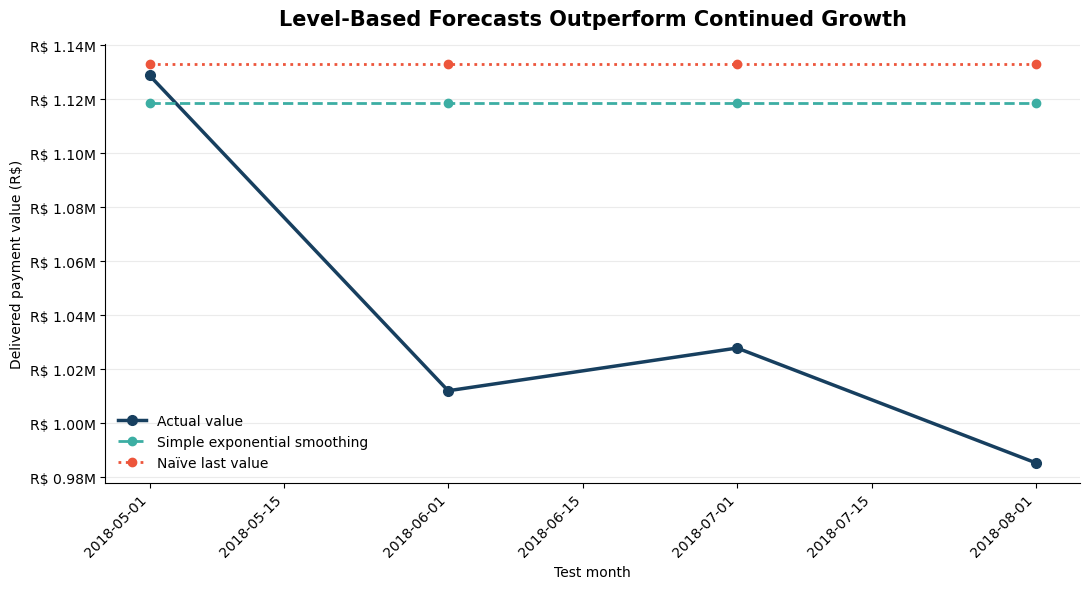

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    test_revenue["purchase_month_start"],
    actual_test_values,
    marker="o",
    markersize=7,
    linewidth=2.5,
    color=COLORS["primary"],
    label="Actual value"
)

ax.plot(
    test_revenue["purchase_month_start"],
    baseline_predictions[
        "Simple exponential smoothing"
    ],
    marker="o",
    linewidth=2,
    linestyle="--",
    color=COLORS["positive"],
    label="Simple exponential smoothing"
)

ax.plot(
    test_revenue["purchase_month_start"],
    baseline_predictions[
        "Naive last value"
    ],
    marker="o",
    linewidth=2,
    linestyle=":",
    color=COLORS["negative"],
    label="Naïve last value"
)

ax.set_title(
    "Level-Based Forecasts Outperform Continued Growth",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Test month")
ax.set_ylabel("Delivered payment value (R$)")

ax.yaxis.set_major_formatter(
    lambda value, position: (
        f"R$ {value / 1_000_000:.2f}M"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower left"
)

fig.autofmt_xdate(
    rotation=45,
    ha="right"
)

plt.tight_layout()

output_path = (
    IMAGES_DIR
    / "revenue_forecast_holdout_comparison.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

***Observation:*** Both level-based forecasts remain above the actual values after May 2018, but simple exponential smoothing stays closer to the observed test series. The chart also shows that forecast uncertainty increases in practical importance across multiple months, especially with only 20 historical observations.

## 9. Generate an Illustrative Historical Projection

Refit the selected model on all 20 comparable months and generate a four-month point projection. These values demonstrate the forecasting workflow and are not estimates of current Olist revenue.

In [10]:
selected_model = SimpleExpSmoothing(
    monthly_revenue[
        "delivered_payment_value"
    ].astype(float).to_numpy(),
    initialization_method="estimated"
).fit(
    optimized=True
)

projection_horizon = 4

projection_months = pd.date_range(
    monthly_revenue[
        "purchase_month_start"
    ].max() + pd.DateOffset(months=1),
    periods=projection_horizon,
    freq="MS"
)

projected_values = selected_model.forecast(
    projection_horizon
)

historical_projection = pd.DataFrame({
    "purchase_month_start":
        projection_months,

    "projected_delivered_payment_value":
        np.asarray(projected_values),

    "model":
        "Simple exponential smoothing"
})

display(
    historical_projection.style.format({
        "purchase_month_start": lambda value: (
            value.strftime("%Y-%m")
        ),
        "projected_delivered_payment_value":
            "R$ {:,.2f}"
    })
)

print(
    "Selected model:",
    "Simple exponential smoothing"
)

print(
    "Projection horizon:",
    f"{projection_horizon} months"
)

print(
    "Important:",
    "Illustrative historical projection only"
)

,purchase_month_start,projected_delivered_payment_value,model
0,2018-09,"R$ 998,584.48",Simple exponential smoothing
1,2018-10,"R$ 998,584.48",Simple exponential smoothing
2,2018-11,"R$ 998,584.48",Simple exponential smoothing
3,2018-12,"R$ 998,584.48",Simple exponential smoothing


Selected model: Simple exponential smoothing
Projection horizon: 4 months
Important: Illustrative historical projection only


***Observation:*** The refitted model produces a level projection of approximately R$998,584 per month from September through December 2018. This constant forecast reflects the model’s estimate of the series’ latest underlying level; it does not capture seasonality, promotional events, or changing market conditions and should be treated only as an illustrative historical projection.

## 10. Validate the Forecasting Workflow

Confirm the completeness of the monthly series, chronological split, prediction tables, rolling evaluation, and final historical projection.

In [11]:
selected_model_name = (
    rolling_validation_metrics.iloc[0]["model"]
)

holdout_best_model = (
    forecast_model_comparison.iloc[0]["model"]
)

forecast_validation = pd.DataFrame({
    "validation_check": [
        "Monthly observations represented",
        "Missing modeling months",
        "Duplicate monthly records",
        "Training observations",
        "Test observations",
        "Chronological train-test split",
        "Models evaluated on holdout period",
        "Rolling prediction records",
        "Missing rolling predictions",
        "Negative forecast values",
        "Selected model matches holdout winner",
        "Historical projection months"
    ],
    "result": [
        len(monthly_revenue),
        len(missing_months),
        duplicate_months,
        len(train_revenue),
        len(test_revenue),
        int(train_end < test_start),
        len(forecast_model_comparison),
        len(rolling_predictions),
        rolling_predictions[
            "predicted_value"
        ].isna().sum(),
        (
            rolling_predictions[
                "predicted_value"
            ].lt(0).sum()
            + historical_projection[
                "projected_delivered_payment_value"
            ].lt(0).sum()
        ),
        int(
            selected_model_name
            == holdout_best_model
        ),
        len(historical_projection)
    ],
    "expected": [
        len(expected_months),
        0,
        0,
        16,
        4,
        1,
        7,
        8 * 7,
        0,
        0,
        1,
        projection_horizon
    ]
})

forecast_validation["status"] = np.where(
    forecast_validation["result"]
    == forecast_validation["expected"],
    "Passed",
    "Failed"
)

display(
    forecast_validation.style.format({
        "result": "{:,.0f}",
        "expected": "{:,.0f}"
    })
)

print(
    "Selected model:",
    selected_model_name
)

,validation_check,result,expected,status
0,Monthly observations represented,20,20,Passed
1,Missing modeling months,0,0,Passed
2,Duplicate monthly records,0,0,Passed
3,Training observations,16,16,Passed
4,Test observations,4,4,Passed
5,Chronological train-test split,1,1,Passed
6,Models evaluated on holdout period,7,7,Passed
7,Rolling prediction records,56,56,Passed
8,Missing rolling predictions,0,0,Passed
9,Negative forecast values,0,0,Passed


Selected model: Simple exponential smoothing


***Observation:*** All validation checks passed. The workflow uses a complete 20-month series, preserves the chronological train-test boundary, evaluates all seven methods consistently, and selects simple exponential smoothing as the best-performing method in both holdout and rolling-origin validation.

## 11. Export Forecasting Results

Export the historical series, model predictions, evaluation metrics, rolling-validation results, projection, and validation report for portfolio reporting.

In [12]:
forecast_export_files = {
    "forecast_monthly_revenue.csv":
        monthly_revenue,

    "forecast_holdout_predictions.csv":
        baseline_predictions,

    "forecast_holdout_metrics.csv":
        forecast_model_comparison,

    "forecast_rolling_predictions.csv":
        rolling_predictions,

    "forecast_rolling_validation_metrics.csv":
        rolling_validation_metrics,

    "forecast_historical_projection.csv":
        historical_projection,

    "forecast_validation.csv":
        forecast_validation
}

for filename, dataframe in (
    forecast_export_files.items()
):
    dataframe.to_csv(
        DATA_DIR / filename,
        index=False
    )

all_forecast_files_created = all(
    (DATA_DIR / filename).exists()
    for filename in forecast_export_files
)

print(
    "Forecasting files exported:",
    len(forecast_export_files)
)

print(
    "All forecasting files created:",
    all_forecast_files_created
)

Forecasting files exported: 7
All forecasting files created: True


***Observation:*** All seven forecasting files were exported successfully. The outputs preserve the complete workflow, including the historical series, holdout comparison, rolling-origin evaluation, selected-model projection, and final validation results.

## 12. Conclusion

***Conclusion:*** This notebook developed a historical revenue-forecasting workflow using 20 consecutive months of delivered-order payment values. Seven forecasting methods were evaluated through a four-month chronological holdout and eight rolling one-month forecasts.

Simple exponential smoothing produced the strongest results in both evaluations. It achieved a holdout MAE of BRL 85,191.93 and WAPE of 8.20%, followed by the last-value baseline with a WAPE of 9.09%. During rolling-origin validation, simple exponential smoothing also ranked first with an MAE of BRL 77,891.81 and WAPE of 7.37%.

Trend-based models overpredicted after revenue stabilized in 2018, while the seasonal-naïve method performed poorly because the earlier year contained substantially lower payment values. After refitting the selected model to all comparable observations, the illustrative projection remained approximately R$998,584 per month from September through December 2018.

The findings demonstrate time-based validation, baseline comparison, model selection, and historical projection techniques. However, the dataset contains only 20 comparable monthly observations and does not include external factors such as promotions, pricing changes, seller growth, or market conditions. Consequently, the projected values should be treated as an offline modeling demonstration rather than current or business-ready revenue forecasts.